# Infrared Solar Modules: Fault vs Normal CNN with 2-Class Softmax (TensorFlow/Keras)

---

**Nguyen Sy Hung (ID: 25MSA33055), 2026**

Machine Learning 1, MLE501.22, FSB

---

This notebook builds a **2-class categorical classifier** on the **Infrared Solar Modules** dataset by collapsing the original classes into:

- **normal** = `No-Anomaly`
- **fault** = every other original anomaly class

The goal is to keep the model **small, fast, and practical** while also returning an explicit **softmax probability distribution** such as:

- `fault = 0.80`
- `normal = 0.20`

That means this notebook uses a **2-unit softmax output** instead of a single-logit binary head.

## Model Architecture

```text
Input
Conv(32) -> BN -> ReLU -> MaxPool
Conv(64) -> BN -> ReLU -> MaxPool
Conv(96) -> BN -> ReLU -> MaxPool
GAP
Dense(32) -> ReLU
Dropout(0.2)
Dense(2) -> Softmax
```

## Training setup:
- BATCH_SIZE = 32
- EPOCHS = 20
- Train: 70%, Validation: 15%, Test: 15%
- Optimizer: AdamW
- Loss: Sparse categorical cross-entropy
- Monitored validation metric: validation accuracy
- Early stopping: restores the best weights

## Notebook flow

1. Load the dataset from `module_metadata.json`
2. Run very light EDA
3. Preprocess images and collapse labels to 2 classes
4. Split into train / validation / test
5. Train a compact CNN with **2-class softmax**
6. Inspect predicted probabilities
7. Evaluate on the test set


In [3]:

# If needed on a fresh environment, uncomment:
# !pip install -q tensorflow scikit-learn pandas pillow matplotlib seaborn


In [4]:
import os
import json
import random
import platform
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    accuracy_score,
 )

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

os.environ["ONEDNN_VERBOSE"] = "none"
os.environ["DNNL_VERBOSE"] = "0"
warnings.filterwarnings("ignore", category=UserWarning)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.15.1


## Configuration

Set `DATASET_DIR` to the root folder of the extracted **Infrared Solar Modules** dataset.

This notebook is aligned to the dataset format defined by **`module_metadata.json`**:

```text
DATASET_DIR/
    module_metadata.json
    images/
        0.jpg
        1.jpg
        2.jpg
        ...
```

Each metadata entry contains at least:

- `image_filepath`
- `anomaly_class`

The binary experiment is then built by mapping:

- `No-Anomaly` -> `normal`
- everything else -> `fault`


In [5]:
# Configuration
DATASET_DIR = Path("/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/classwork/solar/dataset/2020-02-14_InfraredSolarModules/InfraredSolarModules") 
MODULE_METADATA_PATH = DATASET_DIR / "module_metadata.json"

IMG_HEIGHT = 24
IMG_WIDTH = 40
CHANNELS = 1

BATCH_SIZE = 32
EPOCHS = 20
SEED = 36

CLASS_NAMES = ["normal", "fault"]   # label 0 = normal, label 1 = fault
NUM_CLASSES = len(CLASS_NAMES)

AUTOTUNE = tf.data.AUTOTUNE

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

NORMAL_CLASS_NAMES = {
    "no-anomaly", "no_anomaly", "no anomaly", "normal", "noanomaly"
}

# Run artifacts
MODELS_PARENT_DIR = Path("/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/classwork/solar/models")
RUN_ID = time.strftime("%Y%m%d-%H%M%S")
RUN_DIR = MODELS_PARENT_DIR / RUN_ID
RUN_DIR.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = RUN_DIR / "best_fault_vs_normal_softmax_cnn.keras"
FINAL_MODEL_PATH = RUN_DIR / "fault_vs_normal_softmax_cnn_final.keras"
HISTORY_CSV_PATH = RUN_DIR / "history.csv"
TRAINING_CURVES_PATH = RUN_DIR / "training_curves.png"
VAL_PREVIEW_PATH = RUN_DIR / "validation_predictions.csv"
TEST_PREVIEW_PATH = RUN_DIR / "test_predictions.csv"
METRICS_JSON_PATH = RUN_DIR / "metrics_summary.json"
CONFUSION_MATRIX_PATH = RUN_DIR / "test_confusion_matrix.png"
TIMING_JSON_PATH = RUN_DIR / "timing_summary.json"

# Input pipeline knobs
# Using shuffle(len(train_df)) forces TensorFlow to fill a buffer as large as the
# whole training set before the first batch, which is why ShuffleDatasetV3 feels slow.
# A smaller buffer usually gives nearly all the statistical benefit with much less startup delay.
SHUFFLE_BUFFER_SIZE = 2048
CACHE_DATASETS = True
TFDATA_DETERMINISTIC = False

print(f"Run ID      : {RUN_ID}")
print(f"Artifacts   : {RUN_DIR.resolve()}")

# Runtime device selection
# Mirrors the XPU/GPU/CPU runtime logic used in logmel_cnn_v2_2.py
def _best_effort_set_memory_growth(tf_module, device_type: str):
    devices = tf_module.config.list_physical_devices(device_type)
    for device in devices:
        try:
            tf_module.config.experimental.set_memory_growth(device, True)
        except Exception:
            pass
    return devices

def _smoke_test_matmul(tf_module, device: str, n: int = 512):
    try:
        with tf.device(device):
            a = tf_module.random.normal([n, n])
            b = tf_module.random.normal([n, n])
            c = tf_module.matmul(a, b)
            _ = c[0, 0].numpy()
        return True, "ok"
    except Exception as exc:
        return False, repr(exc)

def configure_runtime_device(tf_module):
    print(f"Platform   : {platform.platform()}")
    print(f"TensorFlow : {tf_module.__version__}")

    try:
        gpus = _best_effort_set_memory_growth(tf_module, "GPU")
    except Exception:
        gpus = []

    if gpus:
        ok, info = _smoke_test_matmul(tf_module, "/GPU:0")
        if ok:
            return "/GPU:0", "cuda", [d.name for d in gpus], info
        print("CUDA present but failed smoke test ->", info)

    try:
        import importlib
        importlib.import_module("intel_extension_for_tensorflow")
        xpus = _best_effort_set_memory_growth(tf_module, "XPU")
    except Exception as exc:
        xpus = []
        print("ITEX/XPU not available:", repr(exc))

    if xpus:
        ok, info = _smoke_test_matmul(tf_module, "/XPU:0")
        if ok:
            return "/XPU:0", "xpu", [d.name for d in xpus], info
        print("XPU present but failed smoke test ->", info)

    return "/CPU:0", "cpu", [], "ok"

RUNTIME_DEVICE, BACKEND, ACCEL_NAMES, SMOKE_INFO = configure_runtime_device(tf)
print(f"Backend    : {BACKEND.upper()} ({RUNTIME_DEVICE})")
print(f"Devices    : {ACCEL_NAMES if ACCEL_NAMES else 'none detected -> CPU fallback'}")
print(f"Smoke test : {SMOKE_INFO}")


Run ID      : 20260315-090937
Artifacts   : /mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/classwork/solar/models/20260315-090937
Platform   : Linux-6.6.87.2-microsoft-standard-WSL2-x86_64-with-glibc2.39
TensorFlow : 2.15.1


2026-03-15 09:09:41.720756: I tensorflow/core/common_runtime/next_pluggable_device/next_pluggable_device_factory.cc:118] Created 1 TensorFlow NextPluggableDevices. Physical device type: XPU


Backend    : XPU (/XPU:0)
Devices    : ['/physical_device:XPU:0']
Smoke test : ok


In [6]:
def normalize_class_name(name: str) -> str:
    return name.strip().lower().replace("_", "-")

def binary_label_from_class(original_class: str) -> int:
    norm = normalize_class_name(original_class)
    return 0 if norm in NORMAL_CLASS_NAMES else 1  # 0 = normal, 1 = fault

def load_dataset_from_metadata(dataset_dir: Path, metadata_path: Path) -> pd.DataFrame:
    if not dataset_dir.exists():
        raise FileNotFoundError(
            f"DATASET_DIR does not exist: {dataset_dir}\n"
            "Update DATASET_DIR to the extracted dataset folder."
        )
    if not metadata_path.exists():
        raise FileNotFoundError(
            f"module_metadata.json not found: {metadata_path}\n"
            "This notebook expects the RaptorMaps-style metadata file."
        )

    payload = json.loads(metadata_path.read_text(encoding="utf-8"))
    rows = []

    for module_id, record in payload.items():
        rel_path = record.get("image_filepath")
        original_class = record.get("anomaly_class")

        if rel_path is None or original_class is None:
            continue

        abs_path = dataset_dir / rel_path
        if not abs_path.exists():
            continue

        binary_label = binary_label_from_class(original_class)
        rows.append(
            {
                "module_id": str(module_id),
                "filepath": str(abs_path),
                "relative_filepath": rel_path,
                "original_class": original_class,
                "binary_label": binary_label,
                "binary_class": CLASS_NAMES[binary_label],
            }
        )

    df = pd.DataFrame(rows)
    if df.empty:
        raise ValueError("No valid image rows could be built from module_metadata.json.")
    return df

df = load_dataset_from_metadata(DATASET_DIR, MODULE_METADATA_PATH)
df.head()


,module_id,filepath,relative_filepath,original_class,binary_label,binary_class
0,13357,/mnt/d/mse/nguyen_sy_hung_codebases/machine-le...,images/13357.jpg,No-Anomaly,0,normal
1,13356,/mnt/d/mse/nguyen_sy_hung_codebases/machine-le...,images/13356.jpg,No-Anomaly,0,normal
2,19719,/mnt/d/mse/nguyen_sy_hung_codebases/machine-le...,images/19719.jpg,No-Anomaly,0,normal
3,11542,/mnt/d/mse/nguyen_sy_hung_codebases/machine-le...,images/11542.jpg,No-Anomaly,0,normal
4,11543,/mnt/d/mse/nguyen_sy_hung_codebases/machine-le...,images/11543.jpg,No-Anomaly,0,normal


## Quick EDA

In [7]:
# Basic dataset metrics
n_images = len(df)
n_original_classes = df["original_class"].nunique()
binary_counts = df["binary_class"].value_counts().reindex(CLASS_NAMES, fill_value=0)
original_counts = df["original_class"].value_counts().sort_values(ascending=False)

# Read image sizes (core metric only)
sizes = []
for fp in df["filepath"]:
    with Image.open(fp) as im:
        sizes.append(im.size)  # (width, height)

size_series = pd.Series(sizes)
unique_sizes = size_series.value_counts()

print(f"Total images         : {n_images:,}")
print(f"Original class count : {n_original_classes}")
print("Binary class counts  :")
display(binary_counts.to_frame("count"))
print("Most common image sizes (width, height):")
display(unique_sizes.head(10).rename("count").to_frame())


Total images         : 20,000
Original class count : 12
Binary class counts  :


,count
binary_class,
normal,10000
fault,10000


Most common image sizes (width, height):


,count
"(24, 40)",20000


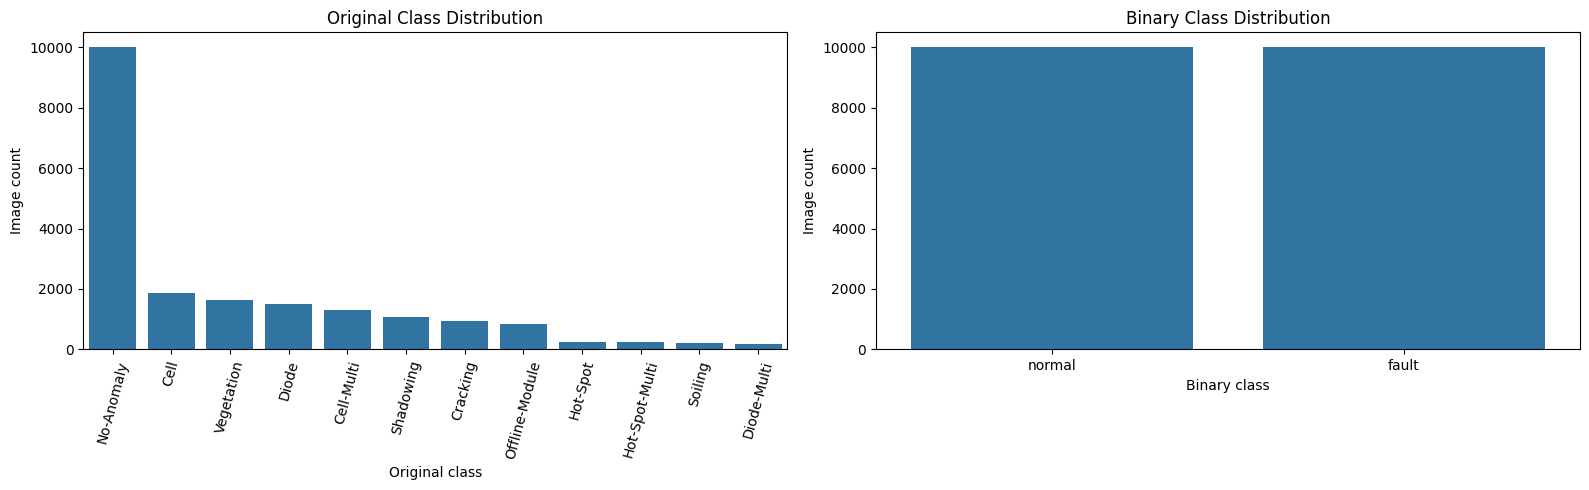

In [8]:

 # EDA Plot 1: original class distribution + binary class distribution
_, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(
    x=original_counts.index,
    y=original_counts.values,
    ax=axes[0],
)
axes[0].set_title("Original Class Distribution")
axes[0].set_xlabel("Original class")
axes[0].set_ylabel("Image count")
axes[0].tick_params(axis="x", rotation=75)

sns.barplot(
    x=binary_counts.index,
    y=binary_counts.values,
    ax=axes[1],
)
axes[1].set_title("Binary Class Distribution")
axes[1].set_xlabel("Binary class")
axes[1].set_ylabel("Image count")

plt.tight_layout()
plt.show()


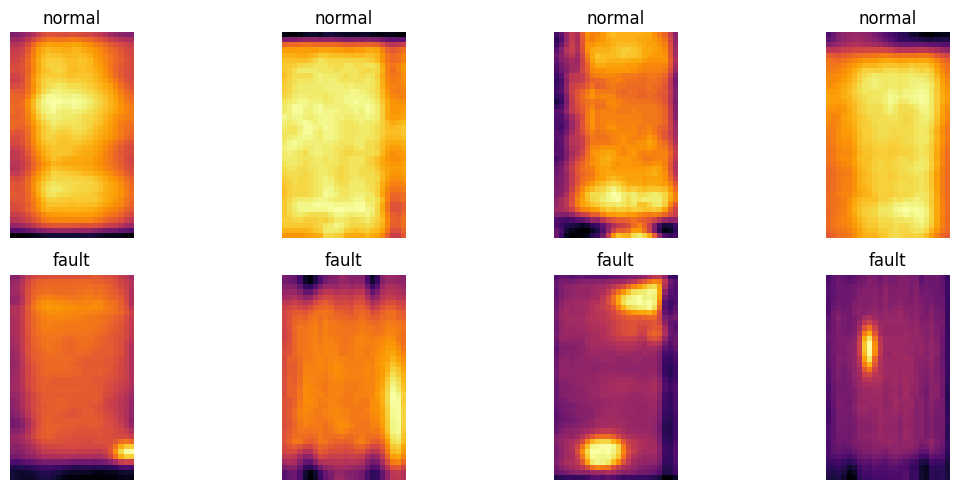

In [9]:

# EDA Plot 2: a few sample thermal images
def show_random_samples(dataframe, n_per_class=4):
    classes = ["normal", "fault"]
    _, axes = plt.subplots(len(classes), n_per_class, figsize=(3*n_per_class, 5))

    if len(classes) == 1:
        axes = np.array([axes])

    for row_idx, cls in enumerate(classes):
        subset = dataframe[dataframe["binary_class"] == cls].sample(
            n=min(n_per_class, len(dataframe[dataframe["binary_class"] == cls])),
            random_state=SEED
        )

        for col_idx in range(n_per_class):
            ax = axes[row_idx, col_idx]
            if col_idx < len(subset):
                img_path = subset.iloc[col_idx]["filepath"]
                with Image.open(img_path) as im:
                    ax.imshow(np.array(im), cmap="inferno")
                ax.set_title(cls)
            ax.axis("off")

    plt.tight_layout()
    plt.show()

show_random_samples(df)


## Split the data

We use a **stratified** split so the dataset remains stable across train, validation, and test.

To better preserve the underlying source distribution, the split is stratified by the **original anomaly class** first, not only by the collapsed binary label.

- Train: 70%
- Validation: 15%
- Test: 15%


In [10]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["original_class"],
    random_state=SEED,
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["original_class"],
    random_state=SEED,
)

print("Train size:", len(train_df))
print("Val size  :", len(val_df))
print("Test size :", len(test_df))

for name, split_df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    counts = split_df["binary_class"].value_counts(normalize=True).reindex(CLASS_NAMES, fill_value=0)
    print(f"\n{name} binary ratio:")
    print(counts)


Train size: 14000
Val size  : 3000
Test size : 3000

train binary ratio:
binary_class
normal    0.5
fault     0.5
Name: proportion, dtype: float64

val binary ratio:
binary_class
normal    0.5
fault     0.5
Name: proportion, dtype: float64

test binary ratio:
binary_class
normal    0.5
fault     0.5
Name: proportion, dtype: float64


## Preprocessing and augmentation

### Preprocessing
- load as grayscale
- resize to `(24, 40)`
- convert to float
- scale pixels to `[0, 1]`

### Labels
We keep integer labels:

- `0 = normal`
- `1 = fault`

The model then learns a **2-class softmax** over these two categories.

### Training augmentation
- left-right flip
- up-down flip
- slight brightness jitter

These are intentionally **light**. Thermal images are not the place for aggressive visual circus tricks.


### XPU training fix for augmentation

The original notebook used Keras preprocessing layers such as `RandomFlip` and `RandomBrightness`.
On Intel XPU via ITEX, those layers may trigger a runtime error:

`Unsupported algorithm id: 3`

That failure comes from the **stateful random-number generator path** used by those layers, not from `model.fit` itself.

This notebook version fixes the problem by:

- moving augmentation into the `tf.data` pipeline
- using `tf.image.stateless_random_*` ops
- forcing the augmentation function onto **CPU**
- keeping the **model training itself** on the selected runtime device (`XPU`, `GPU`, or `CPU`)

So the cheap random augmentation stays on CPU, while the actual neural network still uses the accelerator.


In [11]:

def decode_resize_normalize(filepath, label):
    image_bytes = tf.io.read_file(filepath)
    image = tf.io.decode_image(image_bytes, channels=1, expand_animations=False)
    image.set_shape([None, None, 1])
    image = tf.image.resize(image, [IMG_HEIGHT, IMG_WIDTH])
    image = tf.cast(image, tf.float32) / 255.0
    return image, tf.cast(label, tf.int32)

# ------------------------------------------------------------------
# XPU-safe augmentation
# ------------------------------------------------------------------
# Keras RandomFlip / RandomBrightness can trigger a stateful RNG path on ITEX/XPU.
# We instead do lightweight stateless augmentation inside tf.data and pin it to CPU.
ENABLE_AUGMENTATION = True

def augment_on_cpu_stateless(image, label):
    with tf.device("/CPU:0"):
        seed = tf.random.uniform(shape=[2], minval=0, maxval=2**31 - 1, dtype=tf.int32)
        image = tf.image.stateless_random_flip_left_right(image, seed=seed)

        seed = tf.random.uniform(shape=[2], minval=0, maxval=2**31 - 1, dtype=tf.int32)
        image = tf.image.stateless_random_flip_up_down(image, seed=seed)

        seed = tf.random.uniform(shape=[2], minval=0, maxval=2**31 - 1, dtype=tf.int32)
        image = tf.image.stateless_random_brightness(image, max_delta=0.08, seed=seed)
        image = tf.clip_by_value(image, 0.0, 1.0)

    return image, label

def make_dataset(dataframe, training=False):
    ds = tf.data.Dataset.from_tensor_slices(
        (dataframe["filepath"].values, dataframe["binary_label"].values.astype("int32"))
    )

    options = tf.data.Options()
    options.experimental_deterministic = TFDATA_DETERMINISTIC if training else True
    ds = ds.with_options(options)

    ds = ds.map(decode_resize_normalize, num_parallel_calls=AUTOTUNE)

    # Cache after decode/resize/normalize so repeated epochs do not keep re-reading files.
    # Keep augmentation AFTER cache so each epoch still gets fresh random variants.
    if CACHE_DATASETS:
        ds = ds.cache()

    if training:
        ds = ds.shuffle(
            buffer_size=min(len(dataframe), SHUFFLE_BUFFER_SIZE),
            seed=SEED,
            reshuffle_each_iteration=True,
        )
        if ENABLE_AUGMENTATION:
            ds = ds.map(augment_on_cpu_stateless, num_parallel_calls=AUTOTUNE)

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df, training=False)
test_ds = make_dataset(test_df, training=False)

print(f"Train shuffle buffer size: {min(len(train_df), SHUFFLE_BUFFER_SIZE)}")
print(f"Dataset cache enabled    : {CACHE_DATASETS}")
print(f"Deterministic train pipe : {TFDATA_DETERMINISTIC}")


Train shuffle buffer size: 2048
Dataset cache enabled    : True
Deterministic train pipe : False


## Build the compact CNN

The convolutional backbone stays compact, but the output head is now:

- `Dense(2, activation="softmax")`

This makes the model return an explicit categorical distribution:

- `P(normal | image)`
- `P(fault | image)`


In [12]:
def conv_bn_relu(x, filters, kernel_size=3):
    x = layers.Conv2D(filters, kernel_size, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    return x

def build_model(input_shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS), num_classes=NUM_CLASSES):
    inputs = keras.Input(shape=input_shape)

    x = conv_bn_relu(inputs, 32)
    x = layers.MaxPooling2D(pool_size=2)(x)

    x = conv_bn_relu(x, 64)
    x = layers.MaxPooling2D(pool_size=2)(x)

    x = conv_bn_relu(x, 96)
    x = layers.MaxPooling2D(pool_size=2)(x)

    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.Dense(32, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="class_probs")(x)

    model = keras.Model(inputs, outputs, name="fault_vs_normal_softmax_cnn")
    return model

with tf.device(RUNTIME_DEVICE):
    model = build_model()
model.summary()


Model: "fault_vs_normal_softmax_cnn"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 24, 40, 1)]       0         
                                                                 
 conv2d (Conv2D)             (None, 24, 40, 32)        288       
                                                                 
 batch_normalization (Batch  (None, 24, 40, 32)        128       
 Normalization)                                                  
                                                                 
 re_lu (ReLU)                (None, 24, 40, 32)        0         
                                                                 
 max_pooling2d (MaxPooling2  (None, 12, 20, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 12,

## Compile and train

Training setup:
- **Optimizer**: AdamW
- **Loss**: Sparse categorical cross-entropy
- **Monitored validation metric**: validation accuracy
- **Early stopping**: restores the best weights

Because the output is now a **2-class softmax**, the loss switches from BCE-with-logits to **sparse categorical cross-entropy**.


In [13]:

class EpochTimingCallback(keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.epoch_times_s = []
        self.train_start_s = time.perf_counter()

    def on_epoch_begin(self, epoch, logs=None):
        self._epoch_start_s = time.perf_counter()

    def on_epoch_end(self, epoch, logs=None):
        self.epoch_times_s.append(time.perf_counter() - self._epoch_start_s)

    def on_train_end(self, logs=None):
        self.total_train_time_s = time.perf_counter() - self.train_start_s

epoch_timer = EpochTimingCallback()


In [14]:

optimizer = keras.optimizers.AdamW(
    learning_rate=1e-3,
    weight_decay=1e-4
)

with tf.device(RUNTIME_DEVICE):
    model.compile(
        optimizer=optimizer,
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=[
            keras.metrics.SparseCategoricalAccuracy(name="accuracy"),
        ],
    )

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=6,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ModelCheckpoint(
        str(BEST_MODEL_PATH),
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),
    epoch_timer,
]

with tf.device(RUNTIME_DEVICE):
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=callbacks,
    )

history_df = pd.DataFrame(history.history)
history_df["epoch_time_s"] = epoch_timer.epoch_times_s
history_df.to_csv(HISTORY_CSV_PATH, index=False)

timing_payload = {
    "backend": BACKEND,
    "runtime_device": RUNTIME_DEVICE,
    "batch_size": BATCH_SIZE,
    "epochs_requested": EPOCHS,
    "epochs_completed": int(len(epoch_timer.epoch_times_s)),
    "total_train_time_s": float(epoch_timer.total_train_time_s),
    "mean_epoch_time_s": float(np.mean(epoch_timer.epoch_times_s)) if epoch_timer.epoch_times_s else None,
    "median_epoch_time_s": float(np.median(epoch_timer.epoch_times_s)) if epoch_timer.epoch_times_s else None,
    "epoch_times_s": [float(x) for x in epoch_timer.epoch_times_s],
}

with tf.device(RUNTIME_DEVICE):
    model.save(str(FINAL_MODEL_PATH))

with open(TIMING_JSON_PATH, "w", encoding="utf-8") as f:
    json.dump(timing_payload, f, indent=2)

print(f"Saved best checkpoint : {BEST_MODEL_PATH}")
print(f"Saved final model     : {FINAL_MODEL_PATH}")
print(f"Saved history CSV     : {HISTORY_CSV_PATH}")
print(f"Saved timing JSON     : {TIMING_JSON_PATH}")
print(f"Total train time (s)  : {timing_payload['total_train_time_s']:.3f}")
print(f"Mean epoch time (s)   : {timing_payload['mean_epoch_time_s']:.3f}")


Epoch 1/20


2026-03-15 09:13:10.970099: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type XPU is enabled.


438/438 [==============================] - ETA: 0s - loss: 0.5782 - accuracy: 0.6936
Epoch 1: val_accuracy improved from -inf to 0.61967, saving model to /mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/classwork/solar/models/20260315-090937/best_fault_vs_normal_softmax_cnn.keras
438/438 [==============================] - 153s 307ms/step - loss: 0.5782 - accuracy: 0.6936 - val_loss: 0.6396 - val_accuracy: 0.6197
Epoch 2/20
438/438 [==============================] - ETA: 0s - loss: 0.4927 - accuracy: 0.7666
Epoch 2: val_accuracy improved from 0.61967 to 0.73500, saving model to /mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/classwork/solar/models/20260315-090937/best_fault_vs_normal_softmax_cnn.keras
438/438 [==============================] - 160s 365ms/step - loss: 0.4927 - accuracy: 0.7666 - val_loss: 0.4932 - val_accuracy: 0.7350
Epoch 3/20
438/438 [==============================] - ETA: 0s - loss: 0.4674 - accuracy: 0.7836
Epoch 3: val_accuracy improved from 0.73500 to

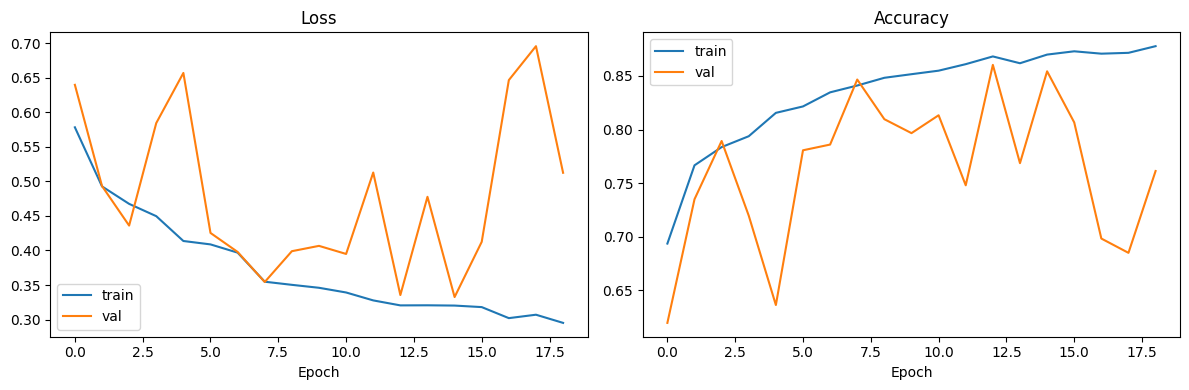

Saved training curves : /mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/classwork/solar/models/20260315-090937/training_curves.png


In [15]:
# Compact training curves
history_df = pd.DataFrame(history.history)

_, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_df["loss"], label="train")
axes[0].plot(history_df["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history_df["accuracy"], label="train")
axes[1].plot(history_df["val_accuracy"], label="val")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig(TRAINING_CURVES_PATH, dpi=160, bbox_inches="tight")
plt.show()

print(f"Saved training curves : {TRAINING_CURVES_PATH}")

## Inspect probability outputs

Since the model uses **softmax**, each prediction already contains a full 2-class probability distribution:

- `normal probability`
- `fault probability`

These two probabilities sum to 1.


In [16]:

def predict_probabilities(model, ds, dataset_name="dataset"):
    start_s = time.perf_counter()
    probs = model.predict(ds, verbose=0)
    total_inference_time_s = time.perf_counter() - start_s

    labels = np.concatenate([y.numpy().ravel() for _, y in ds], axis=0).astype(int)
    pred_idx = np.argmax(probs, axis=1)

    n_samples = int(len(labels))
    avg_time_per_sample_ms = (total_inference_time_s / n_samples) * 1000.0 if n_samples else None

    print(
        f"{dataset_name} inference: total={total_inference_time_s:.4f}s | "
        f"samples={n_samples} | avg={avg_time_per_sample_ms:.4f} ms/sample"
    )

    return labels, probs, pred_idx, {
        "dataset_name": dataset_name,
        "n_samples": n_samples,
        "total_inference_time_s": float(total_inference_time_s),
        "avg_time_per_sample_ms": float(avg_time_per_sample_ms) if avg_time_per_sample_ms is not None else None,
    }

y_val, p_val, y_val_pred, val_inference_timing = predict_probabilities(model, val_ds, dataset_name="validation")

preview_df = pd.DataFrame(
    {
        "normal_probability": p_val[:, 0],
        "fault_probability": p_val[:, 1],
        "predicted_class": [CLASS_NAMES[i] for i in y_val_pred],
        "true_class": [CLASS_NAMES[i] for i in y_val],
    }
)
preview_df.to_csv(VAL_PREVIEW_PATH, index=False)

val_metrics = {
    "accuracy": float(accuracy_score(y_val, y_val_pred)),
    "precision": float(precision_score(y_val, y_val_pred, zero_division=0)),
    "recall": float(recall_score(y_val, y_val_pred, zero_division=0)),
    "f1": float(f1_score(y_val, y_val_pred, zero_division=0)),
    "roc_auc": float(roc_auc_score(y_val, p_val[:, 1])),
}

display(preview_df.head(10))

print("Validation Accuracy :", val_metrics["accuracy"])
print("Validation Precision:", val_metrics["precision"])
print("Validation Recall   :", val_metrics["recall"])
print("Validation F1       :", val_metrics["f1"])
print("Validation ROC-AUC  :", val_metrics["roc_auc"])


validation inference: total=0.6170s | samples=3000 | avg=0.2057 ms/sample


,normal_probability,fault_probability,predicted_class,true_class
0,0.598988,0.401012,normal,normal
1,0.943631,0.056369,normal,normal
2,0.924824,0.075176,normal,normal
3,0.789633,0.210366,normal,normal
4,0.608190,0.391810,normal,normal
5,0.550569,0.449430,normal,fault
6,0.863263,0.136737,normal,normal
7,0.841763,0.158237,normal,normal
8,0.145583,0.854417,fault,fault
9,0.817863,0.182137,normal,normal


Validation Accuracy : 0.8603333333333333
Validation Precision: 0.931364724660814
Validation Recall   : 0.778
Validation F1       : 0.8478023973846712
Validation ROC-AUC  : 0.9350884444444445


## Final evaluation on the test set


In [17]:

y_test, p_test, y_pred, test_inference_timing = predict_probabilities(model, test_ds, dataset_name="test")

test_metrics = {
    "accuracy": float(accuracy_score(y_test, y_pred)),
    "precision": float(precision_score(y_test, y_pred, zero_division=0)),
    "recall": float(recall_score(y_test, y_pred, zero_division=0)),
    "f1": float(f1_score(y_test, y_pred, zero_division=0)),
    "roc_auc": float(roc_auc_score(y_test, p_test[:, 1])),
}

print("Test Accuracy :", test_metrics["accuracy"])
print("Test Precision:", test_metrics["precision"])
print("Test Recall   :", test_metrics["recall"])
print("Test F1       :", test_metrics["f1"])
print("Test ROC-AUC  :", test_metrics["roc_auc"])

print("\nClassification report:")
test_report = classification_report(y_test, y_pred, target_names=CLASS_NAMES, zero_division=0)
print(test_report)

test_preview_df = pd.DataFrame(
    {
        "fault_probability": p_test[:, 1],
        "normal_probability": p_test[:, 0],
        "predicted_class": [CLASS_NAMES[i] for i in y_pred],
        "true_class": [CLASS_NAMES[i] for i in y_test],
    }
).sort_values("fault_probability", ascending=False)
test_preview_df.to_csv(TEST_PREVIEW_PATH, index=False)

metrics_payload = {
    "run_id": RUN_ID,
    "backend": BACKEND,
    "runtime_device": RUNTIME_DEVICE,
    "class_names": CLASS_NAMES,
    "validation_metrics": val_metrics,
    "test_metrics": test_metrics,
    "validation_inference_timing": val_inference_timing,
    "test_inference_timing": test_inference_timing,
    "artifacts": {
        "best_model_path": str(BEST_MODEL_PATH),
        "final_model_path": str(FINAL_MODEL_PATH),
        "history_csv_path": str(HISTORY_CSV_PATH),
        "training_curves_path": str(TRAINING_CURVES_PATH),
        "val_preview_path": str(VAL_PREVIEW_PATH),
        "test_preview_path": str(TEST_PREVIEW_PATH),
        "confusion_matrix_path": str(CONFUSION_MATRIX_PATH),
        "timing_json_path": str(TIMING_JSON_PATH),
    },
}
with open(METRICS_JSON_PATH, "w", encoding="utf-8") as f:
    json.dump(metrics_payload, f, indent=2)

# merge metrics + training timing into one timing file for convenience
try:
    with open(TIMING_JSON_PATH, "r", encoding="utf-8") as f:
        timing_payload = json.load(f)
except Exception:
    timing_payload = {}

timing_payload["validation_inference_timing"] = val_inference_timing
timing_payload["test_inference_timing"] = test_inference_timing

with open(TIMING_JSON_PATH, "w", encoding="utf-8") as f:
    json.dump(timing_payload, f, indent=2)

print(f"Saved validation preview: {VAL_PREVIEW_PATH}")
print(f"Saved test preview      : {TEST_PREVIEW_PATH}")
print(f"Saved metrics JSON      : {METRICS_JSON_PATH}")
print(f"Updated timing JSON     : {TIMING_JSON_PATH}")


test inference: total=1.7257s | samples=3000 | avg=0.5752 ms/sample
Test Accuracy : 0.8526666666666667
Test Precision: 0.9293831168831169
Test Recall   : 0.7633333333333333
Test F1       : 0.8382137628111274
Test ROC-AUC  : 0.9286755555555556

Classification report:
              precision    recall  f1-score   support

      normal       0.80      0.94      0.86      1500
       fault       0.93      0.76      0.84      1500

    accuracy                           0.85      3000
   macro avg       0.86      0.85      0.85      3000
weighted avg       0.86      0.85      0.85      3000

Saved validation preview: /mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/classwork/solar/models/20260315-090937/validation_predictions.csv
Saved test preview      : /mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/classwork/solar/models/20260315-090937/test_predictions.csv
Saved metrics JSON      : /mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/classwork/solar/models/20260315-09093

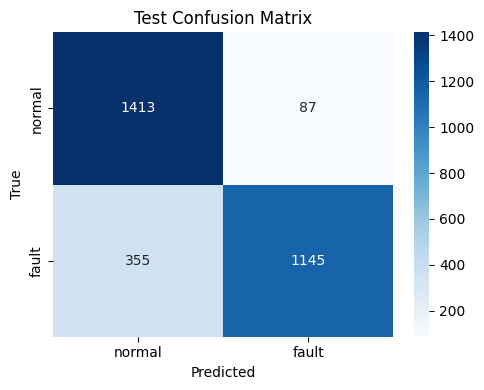

Saved confusion matrix : /mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/classwork/solar/models/20260315-090937/test_confusion_matrix.png


In [18]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Test Confusion Matrix")
plt.tight_layout()
plt.savefig(CONFUSION_MATRIX_PATH, dpi=160, bbox_inches="tight")
plt.show()

print(f"Saved confusion matrix : {CONFUSION_MATRIX_PATH}")

In [19]:
# Save the trained model 
# model.save("fault_vs_normal_cnn_final.keras")
